# Time Series comparison of ozone concentration

In [201]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplcursors

dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 28
mpl.rcParams['axes.xmargin'] = 0

# Set the font family to 'serif'
mpl.rcParams['font.family'] = 'serif'
# Specify preferred serif font (Computer Modern Roman is 'cmr10')
mpl.rcParams['font.serif'] = 'Lato' 
# Optionally, configure mathtext to use Computer Modern fonts as well
mpl.rcParams['mathtext.fontset'] = 'cm'
# Ensure minus signs are rendered correctly with CM fonts
mpl.rcParams['axes.unicode_minus'] = False

mobilelab_hourly_o3_filepath = dirpath + 'USOS_Campaign_analysis/resaved_data/ozone_resampled_hourly.csv'
mobilelab_o3 = pd.read_csv(mobilelab_hourly_o3_filepath,index_col = 'time_local', parse_dates=True)
#display(mobilelab_o3)

udaq_o3_filepath = dirpath + 'Hawthorne_data/data/hawthorne_udaq_o3_2024_timezone_updated.csv'
df_udaq_o3_load = pd.read_csv(udaq_o3_filepath, index_col = 'time_local', parse_dates=True)
#display(df_udaq_o3_load)

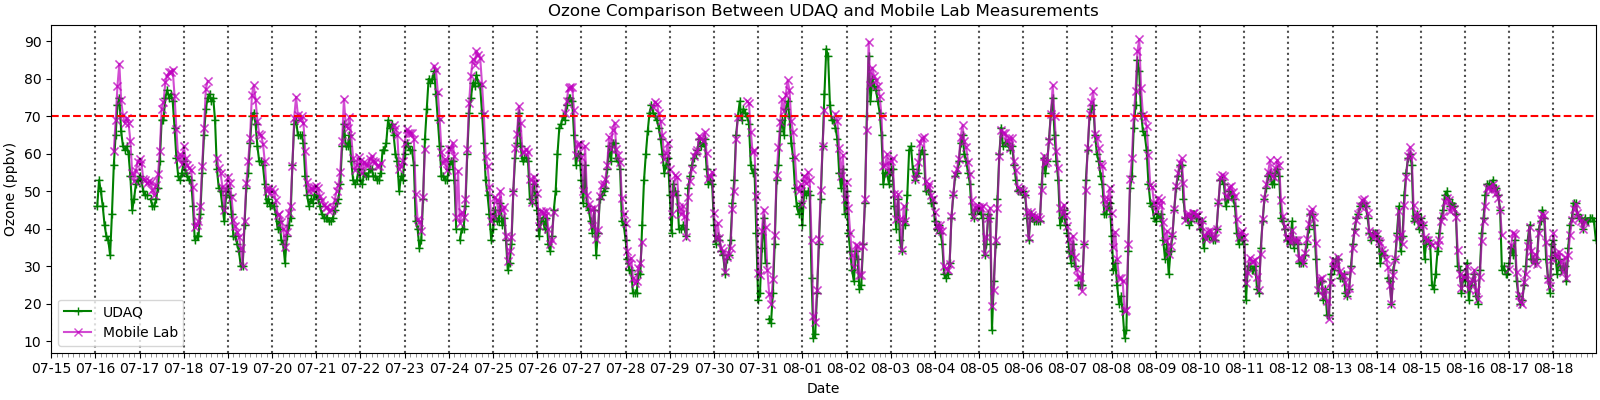

In [ ]:
%matplotlib widget
#Full Time Series Plot
fig, ax = plt.subplots(figsize = (16,4), constrained_layout=True)
ax.plot(mobilelab_o3.index, df_udaq_o3_load['UDAQ O3'], linestyle = 'solid', color = 'g', marker = '+', label = 'UDAQ')
ax.plot(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)

pts1 = ax.scatter(mobilelab_o3.index, df_udaq_o3_load['UDAQ O3'], marker = '+', color='g', label = 'UDAQ', alpha = 0.2)
pts2 = ax.scatter(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], marker='x', color='m', label = 'Mobile Lab', alpha = 0.2)

#print(df_udaq_o3_load.index)
ax.hlines(y=70, xmin = df_udaq_o3_load.index[0], xmax = df_udaq_o3_load.index[len(df_udaq_o3_load.index)-1], linestyle = 'dashed', color = 'r')
#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_udaq_o3_load.index),24):
    midnight_vals.append(df_udaq_o3_load.index[midnight_idx])
for day_pos in midnight_vals:
    ax.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)
#Set x ticks
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax.tick_params(axis='x', which='major')
ax.tick_params(axis='x', which='minor', length=3, color='gray')
#ax.grid(True, which='both')
plt.yticks(np.arange(10,100,10))
plt.ylabel('Ozone (ppbv)')
plt.xlabel('Date')
plt.margins(x=0)

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

plt.title('Ozone Comparison Between UDAQ and Mobile Lab Measurements')
#plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/hawthorne_udaq_mobilelab_o3_comparison_full_campaign.png', dpi =300)
cursor = mplcursors.cursor([pts1,pts2], multiple=True)
@cursor.connect("add")
def on_add(sel):
    dt_x = mdates.num2date(sel.target[0])
    label = sel.artist.get_label()
    sel.annotation.set_text(f"{label}\n{dt_x:%m-%d %H:%M}, [O3] = {sel.target[1]}")

plt.show()

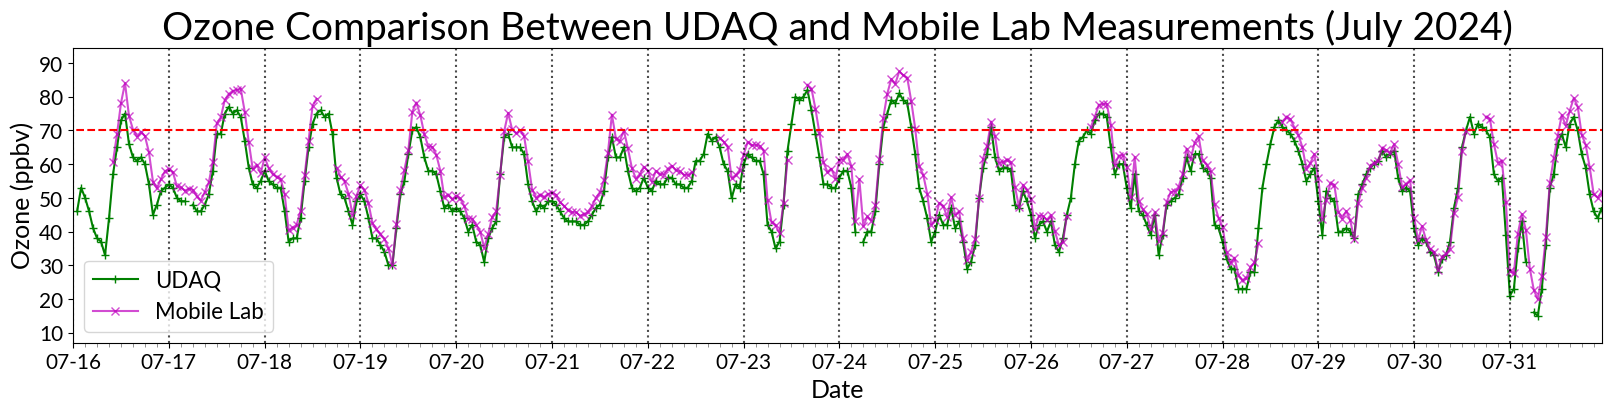

In [241]:
plt.close()
plt.ioff()
%matplotlib inline
#First week time series
fig, ax = plt.subplots(figsize = (16,4), constrained_layout=True)
ax.plot(mobilelab_o3.index, df_udaq_o3_load['UDAQ O3'], linestyle = 'solid', color = 'g', marker = '+', label = 'UDAQ')
ax.plot(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)
#print(df_udaq_o3_load.index)
ax.hlines(y=70, xmin = df_udaq_o3_load.index[0], xmax = df_udaq_o3_load.index[len(df_udaq_o3_load.index)-1], linestyle = 'dashed', color = 'r')
#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_udaq_o3_load.index),24):
    midnight_vals.append(df_udaq_o3_load.index[midnight_idx])
for day_pos in midnight_vals:
    ax.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)
#Set x ticks
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax.tick_params(axis='x', which='major')
ax.tick_params(axis='x', which='minor', length=3, color='gray')
#ax.grid(True, which='both')
plt.yticks(np.arange(10,100,10))
plt.ylabel('Ozone (ppbv)')
plt.xlabel('Date')
plt.margins(x=0)

ax.set_xlim([pd.to_datetime('2024-07-16 00:00:00'), pd.to_datetime('2024-07-31 23:00:00')])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

plt.title('Ozone Comparison Between UDAQ and Mobile Lab Measurements (July 2024)')
plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/hawthorne_udaq_mobilelab_o3_comparison_july.png', dpi =300)
plt.show()



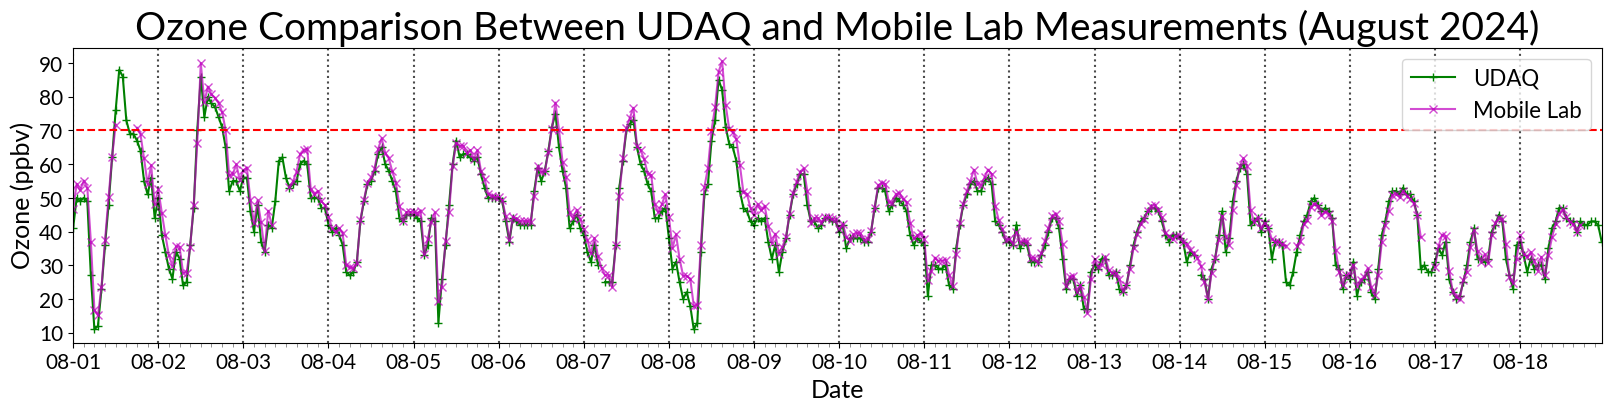

In [204]:
#Second week time series
plt.close()
plt.ioff()
%matplotlib inline
#First week time series
fig, ax = plt.subplots(figsize = (16,4), constrained_layout=True)
ax.plot(mobilelab_o3.index, df_udaq_o3_load['UDAQ O3'], linestyle = 'solid', color = 'g', marker = '+', label = 'UDAQ')
ax.plot(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)
#print(df_udaq_o3_load.index)
ax.hlines(y=70, xmin = df_udaq_o3_load.index[0], xmax = df_udaq_o3_load.index[len(df_udaq_o3_load.index)-1], linestyle = 'dashed', color = 'r')
#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_udaq_o3_load.index),24):
    midnight_vals.append(df_udaq_o3_load.index[midnight_idx])
for day_pos in midnight_vals:
    ax.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)
#Set x ticks
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax.tick_params(axis='x', which='major')
ax.tick_params(axis='x', which='minor', length=3, color='gray')
#ax.grid(True, which='both')
plt.yticks(np.arange(10,100,10))
plt.ylabel('Ozone (ppbv)')
plt.xlabel('Date')
plt.margins(x=0)

ax.set_xlim([pd.to_datetime('2024-08-01 00:00:00'), pd.to_datetime('2024-08-18 23:00:00')])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

plt.title('Ozone Comparison Between UDAQ and Mobile Lab Measurements (August 2024)')
plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/hawthorne_udaq_mobilelab_o3_comparison_full_campaign.png', dpi =300)
plt.show()



## Normalized Mean Bias:

$\text{NMB} = \frac{\sum_{i=1}^n \left(M_i - O_i \right)}{\sum_{i=1}^n (O_i)}$

In [205]:
df_o3 = pd.DataFrame({'obs O3':mobilelab_o3['Mobile Lab O3'], 'model O3':df_udaq_o3_load['UDAQ O3']})

df_o3['O3_diff']= df_o3['model O3']-df_o3['obs O3']
nmb_num = np.nansum(df_o3['O3_diff'])
nmb_den = np.nansum(df_o3['obs O3'])
nmb_total = nmb_num/nmb_den
print(nmb_total)

-0.05163776833216253


The UDAQ instrument underestimates $\text{O}_3$ by 5%.

In [206]:
df_o3['hour']=df_o3.index.hour 
# Repeat, but calculate NMB in each hour seperately: 
sum_hrly_diff=df_o3.groupby('hour')['O3_diff'].apply(np.nansum)
sum_hrly_obs=df_o3.groupby('hour')['obs O3'].apply(np.nansum)
hrly_NMB=sum_hrly_diff/sum_hrly_obs
print(hrly_NMB)

hour
0    -0.063707
1    -0.059534
2    -0.069223
3    -0.061684
4    -0.068022
5    -0.061072
6    -0.091929
7    -0.082957
8    -0.045163
9    -0.014846
10   -0.011624
11   -0.010219
12   -0.021684
13   -0.039453
14   -0.037580
15   -0.040668
16   -0.043951
17   -0.050482
18   -0.056816
19   -0.066669
20   -0.095217
21   -0.054459
22   -0.056933
23   -0.052208
dtype: float64


In [207]:
print(np.min(hrly_NMB)*100*-1)

9.521699003675687


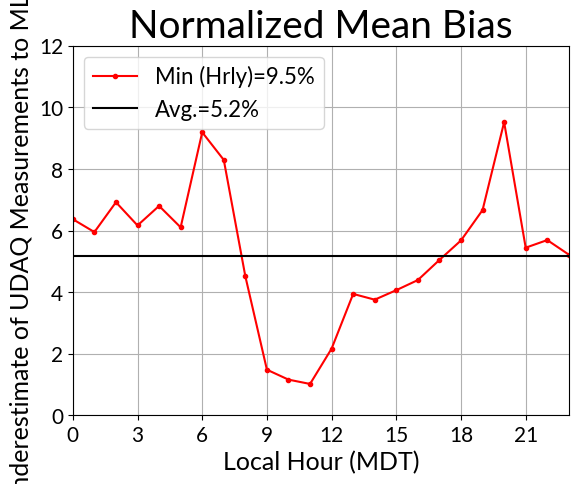

In [208]:
# Plot the hourly NMB and the average over time: 
plt.figure()
plt.plot(hrly_NMB.index,hrly_NMB*100*-1, color='r', marker='.', label=f"Min (Hrly)={np.min(hrly_NMB)*100*-1:.1f}%" )
plt.plot(hrly_NMB.index, np.ones(len(hrly_NMB.index))*nmb_total*100*-1, color='k',label=f"Avg.={nmb_total*-1*100:.1f}%",)
plt.ylim([0, 12])
plt.title('Normalized Mean Bias')
plt.ylabel('Underestimate of UDAQ Measurements to ML (%)')
plt.xlabel('Local Hour (MDT)')
plt.xlim([0, 23])
plt.xticks([0,3,6,9,12,15,18,21])
plt.grid()
plt.legend()
plt.show()

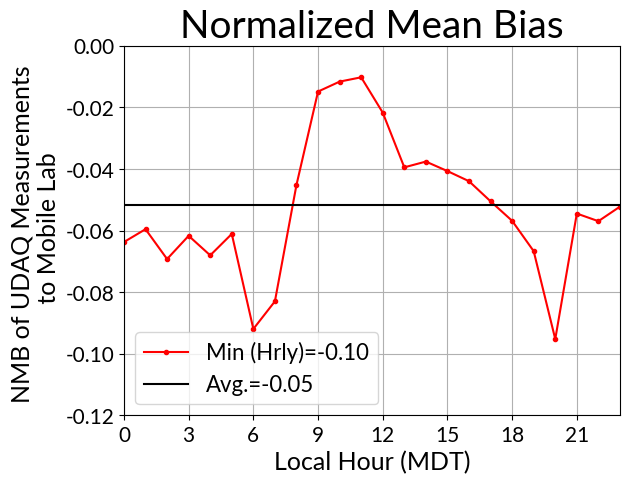

In [225]:
# Plot the hourly NMB and the average over time: 
plt.figure()
plt.plot(hrly_NMB.index, hrly_NMB, color='r', marker='.', label=f"Min (Hrly)={np.min(hrly_NMB):.2f}")
plt.plot(hrly_NMB.index, np.ones(len(hrly_NMB.index))*nmb_total, color='k',label=f"Avg.={nmb_total:.2f}")
plt.ylim([-0.12, 0])
plt.title('Normalized Mean Bias')
plt.ylabel('NMB of UDAQ Measurements \n to Mobile Lab')
plt.xlabel('Local Hour (MDT)')
plt.xlim([0, 23])
plt.xticks([0,3,6,9,12,15,18,21])
plt.grid()
plt.legend()
plt.show()

# Mean Bias

$\text{Mean bias} = \frac{1}{n} \sum_{i=1}^n (M_i - O_i) = \overline{M} - \overline{O}$

Average of differences between predicted & actual values.

In [210]:
df_o3['O3_diff']= df_o3['model O3']-df_o3['obs O3']
mb_num = np.nansum(df_o3['O3_diff'])
mb_total = mb_num * (1/len(df_o3['O3_diff']))
print("UDAQ's instrument on average predicts values ", mb_total*-1, " ppb lower than the Mobile Lab.")

UDAQ's instrument on average predicts values  2.297409797135643  ppb lower than the Mobile Lab.


In [211]:
df_o3['hour']=df_o3.index.hour 
mean_hrly_obs=df_o3.groupby('hour')['obs O3'].apply(np.nanmean)
mean_hrly_udaq=df_o3.groupby('hour')['model O3'].apply(np.nanmean)


-2.1158776888044137
2.1973109225533043


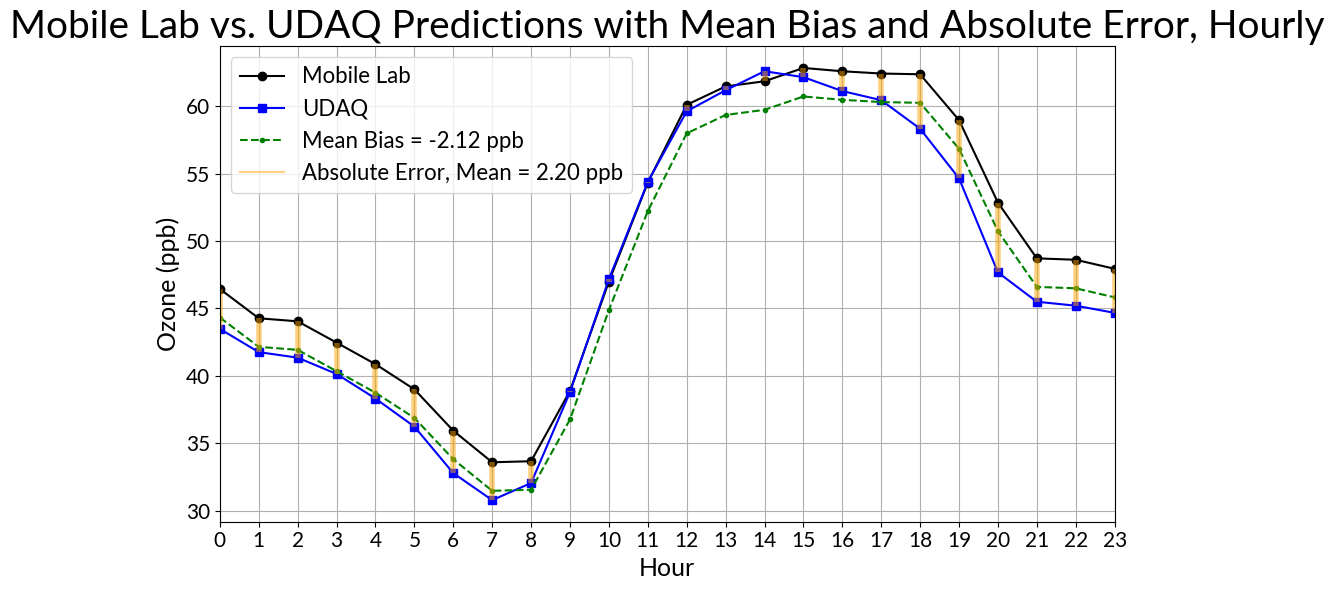

In [ ]:
# import matplotlib.lines as mlines

# hour_range = np.arange(0,24,1)
# plt.figure(figsize=(10,6), tight_layout = True)
# ml_plot = plt.plot(hour_range, mean_hrly_obs, 'o-', label='Mobile Lab', color='black')
# udaq_plot = plt.plot(hour_range, mean_hrly_udaq, 's-', label=f'UDAQ', color='blue')
# mb_a = np.nansum([m - o for m, o in zip(mean_hrly_udaq, mean_hrly_obs)]) / len(mean_hrly_obs)
# print(mb_a)
# mb_line_a = [o + mb_a for o in mean_hrly_obs]
# plt.plot(hour_range, mb_line_a, linestyle = '--', marker = '.', label=f'Mean Bias = {mb_a:.2f} ppb', color='green')

# mae = sum([abs(m - o) for m, o in zip(mean_hrly_udaq, mean_hrly_obs)]) / len(mean_hrly_obs)
# print(mae)
# # Show absolute errors as vertical lines
# for h, o, m in zip(hour_range, mean_hrly_obs, mean_hrly_udaq):
#     plt.vlines(h, min(o, m), max(o, m), color='orange', alpha=0.5, linewidth=4)

# vline_proxy = mlines.Line2D([], [], color='orange', alpha=0.5)

# # Get the current Axes object
# ax = plt.gca()

# # Retrieve handles and labels generated by plt.plot
# handles, labels = ax.get_legend_handles_labels()
# handles.append(vline_proxy)
# labels.append(f'Absolute Error, Mean = {mae:.2f} ppb')

# plt.margins(x=0)
# plt.xlabel('Hour')
# plt.ylabel('Ozone (ppb)')
# plt.title('Mobile Lab vs. UDAQ Obs with Mean Bias and Absolute Error')
# plt.xticks(hour_range)
# plt.legend(handles, labels)
# plt.grid(True)
# plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/udaq_ml_hourly_o3_mean_bias_abs_error_hawthorne.png', dpi =150)
# #plt.tight_layout()
# plt.show()

/tmp/ipykernel_65574/820014328.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_MB = df_o3.groupby('hour').apply(lambda x: (x['model O3'] - x['obs O3']).mean())


Hourly Mean Bias (MB):
hour
0    -2.958778
1    -2.635714
2    -3.049227
3    -2.619621
4    -2.780133
5    -2.807410
6    -3.303972
7    -2.787344
8    -1.520968
9    -0.577378
10   -0.546325
11   -0.555178
12   -1.303147
13   -2.424732
14   -2.324032
15   -2.555183
16   -2.750633
17   -3.150949
18   -3.543101
19   -3.930884
20   -5.032260
21   -2.653014
22   -2.767601
23   -2.502859
dtype: float64


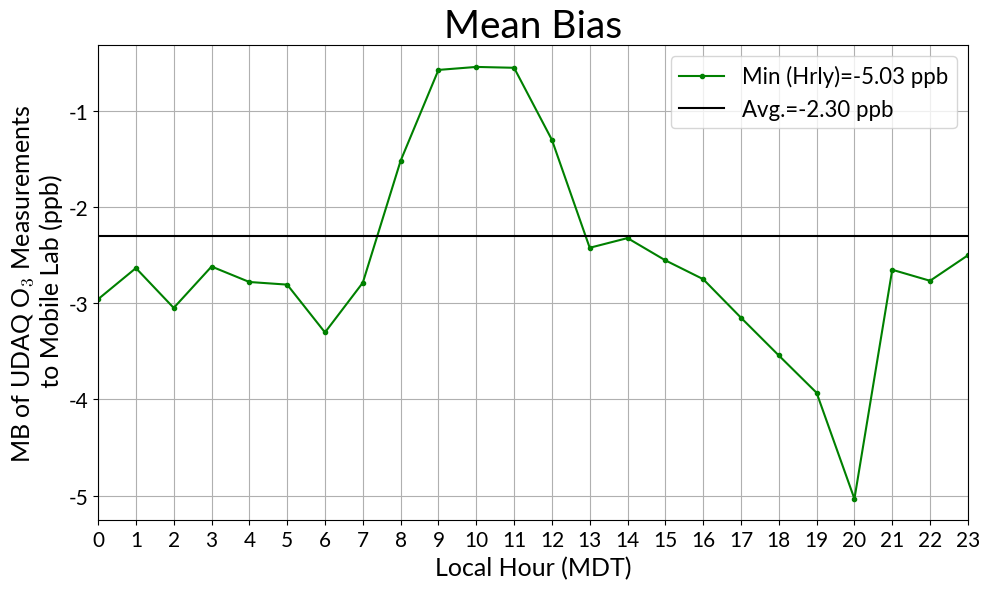

In [230]:
df_o3['hour']=df_o3.index.hour 
hourly_MB = df_o3.groupby('hour').apply(lambda x: (x['model O3'] - x['obs O3']).mean())
print("Hourly Mean Bias (MB):")
print(hourly_MB)
# Plot the hourly Mean Bias and the average over time: 
plt.figure(figsize=(10,6), tight_layout = True)
plt.plot(hourly_MB.index, hourly_MB, color='g', marker='.', label=f"Min (Hrly)={np.min(hourly_MB):.2f} ppb")
plt.plot(hourly_MB.index, np.ones(len(hourly_MB.index))*mb_total, color='k',label=f"Avg.={mb_total:.2f} ppb")
#plt.ylim([-0.14, 0])
plt.title('Mean Bias')
plt.ylabel('MB of UDAQ O$_3$ Measurements \n to Mobile Lab (ppb)')
plt.xlabel('Local Hour (MDT)')
plt.xlim([0, 23])
plt.xticks(hour_range)
plt.grid()
plt.legend()
plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/mean_bias_hourly_o3_hawthorne.png', dpi =150)
plt.show()

2.1973109225533043


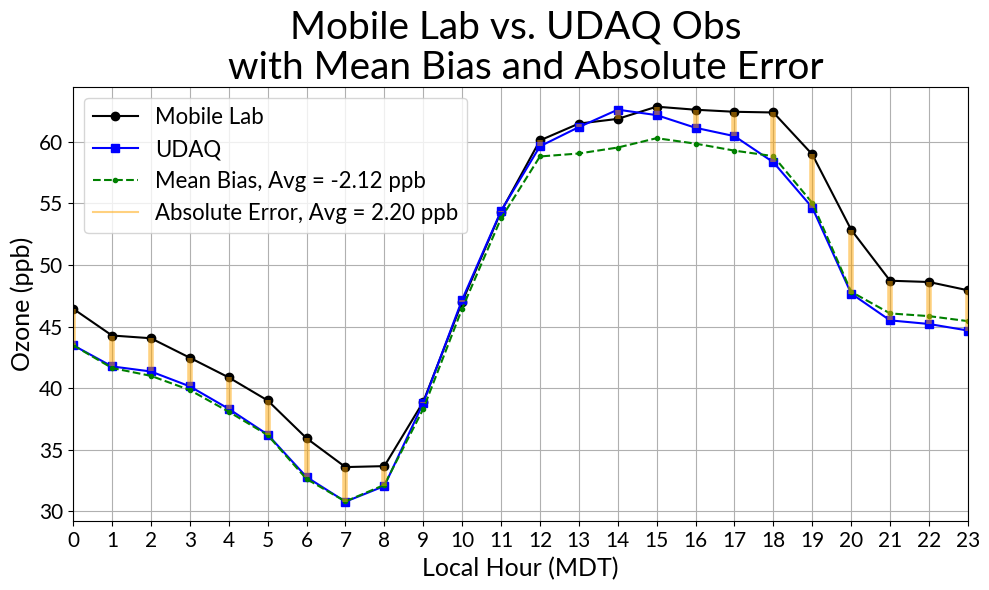

In [234]:
import matplotlib.lines as mlines

hour_range = np.arange(0,24,1)
plt.figure(figsize=(10,6), tight_layout = True)
ml_plot = plt.plot(hour_range, mean_hrly_obs, 'o-', label='Mobile Lab', color='black')
udaq_plot = plt.plot(hour_range, mean_hrly_udaq, 's-', label=f'UDAQ', color='blue')

mb_line_a = hourly_MB + mean_hrly_obs
plt.plot(hour_range, mb_line_a, linestyle = '--', marker = '.', label=f'Mean Bias, Avg = {mb_a:.2f} ppb', color='green')

mae = sum([abs(m - o) for m, o in zip(mean_hrly_udaq, mean_hrly_obs)]) / len(mean_hrly_obs)
print(mae)
# Show absolute errors as vertical lines
for h, o, m in zip(hour_range, mean_hrly_obs, mean_hrly_udaq):
    plt.vlines(h, min(o, m), max(o, m), color='orange', alpha=0.5, linewidth=4)

vline_proxy = mlines.Line2D([], [], color='orange', alpha=0.5)

# Get the current Axes object
ax = plt.gca()

# Retrieve handles and labels generated by plt.plot
handles, labels = ax.get_legend_handles_labels()
handles.append(vline_proxy)
labels.append(f'Absolute Error, Avg = {mae:.2f} ppb')

plt.margins(x=0)
plt.xlabel('Local Hour (MDT)')
plt.ylabel('Ozone (ppb)')
plt.title('Mobile Lab vs. UDAQ Obs \n with Mean Bias and Absolute Error')
plt.xticks(hour_range)
plt.legend(handles, labels)
plt.grid(True)
plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/udaq_ml_hourly_o3_mean_bias_abs_error_hawthorne.png', dpi =150)
#plt.tight_layout()
plt.show()

In [95]:
for hr in range(0,len(mean_hrly_udaq)):
    print(mean_hrly_obs[hr], mean_hrly_udaq[hr])

46.44362660243793 43.484848484848484
44.272077441077435 41.76470588235294
44.04922727272727 41.35294117647059
42.468106060606054 40.14705882352941
40.87104208754209 38.3235294117647
39.00373207643098 36.241379310344826
35.940335172452826 32.794117647058826
33.59984406001147 30.794117647058822
33.67721803598413 32.05882352941177
38.88987771787642 38.794117647058826
46.99793796882783 47.1764705882353
54.32937188070352 54.38235294117647
60.09624995757161 59.61764705882353
61.45921454859544 61.1764705882353
61.84255016901138 62.588235294117645
62.83104502818583 62.14705882352941
62.58396594760813 61.11764705882353
62.41761578639596 60.44117647058823
62.36128330828342 58.3235294117647
58.96118745322629 54.64705882352941
52.85044180938415 47.6764705882353
48.71551422505582 45.5
48.61135069444444 45.205882352941174
47.940359375 44.6764705882353


Mean bias is mostly helpful for informing us if the predictions (UDAQ Measurements) are generally biased up or down. We can tell that on average, the UDAQ measurements regularly underpredict by about 2.12 ppb. The mean absolute error (how far off UDAQ is from ML measurements) is 2.20 ppb. 

## Mean absolute error 
or mean error (sometimes same as mean bias if sign is relevant, called MAE if abs val used)

$\text{MAE} = \frac{1}{n} \sum_{i=1}^n |M_i - O_i| = |\overline{M} - \overline{O}|$

In [47]:
diff_abs_val = np.nansum(abs(df_o3['O3_diff']))
mae_total = (1/len(df_o3['O3_diff'])) *diff_abs_val
print(mae_total)

2.6106985896542896


In [226]:
mae = sum([abs(m - o) for m, o in zip(mean_hrly_udaq, mean_hrly_obs)]) / len(mean_hrly_obs)
print(mae)

2.1973109225533043


/tmp/ipykernel_65574/358100721.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_MBE = df_o3.groupby('hour').apply(lambda x: (abs(x['model O3'] - x['obs O3'])).mean())


Hourly Mean Bias Error (MB):
hour
0     3.078262
1     2.694646
2     3.631328
3     2.661955
4     2.782291
5     3.003081
6     3.314042
7     2.910681
8     2.094634
9     1.686110
10    1.615165
11    1.832848
12    2.153741
13    2.750659
14    2.701391
15    3.010798
16    3.051355
17    3.378582
18    3.679349
19    3.977672
20    5.032260
21    2.754910
22    2.918337
23    2.901769
dtype: float64


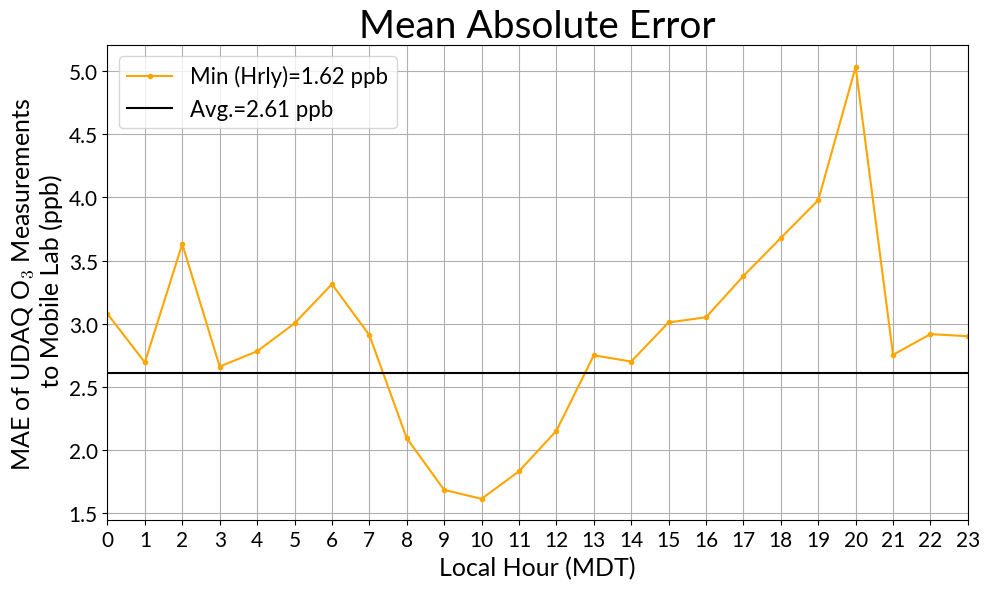

In [233]:
df_o3['hour']=df_o3.index.hour 
hourly_MBE = df_o3.groupby('hour').apply(lambda x: (abs(x['model O3'] - x['obs O3'])).mean())
print("Hourly Mean Bias Error (MB):")
print(hourly_MBE)
# Plot the hourly Mean Bias and the average over time: 
plt.figure(figsize=(10,6), tight_layout = True)
plt.plot(hourly_MBE.index, hourly_MBE, color='orange', marker='.', label=f"Min (Hrly)={np.min(hourly_MBE):.2f} ppb")
plt.plot(hourly_MBE.index, np.ones(len(hourly_MBE.index))*mae_total, color='k',label=f"Avg.={mae_total:.2f} ppb")
#plt.ylim([-0.14, 0])
plt.title('Mean Absolute Error')
plt.ylabel('MAE of UDAQ O$_3$ Measurements \n to Mobile Lab (ppb)')
plt.xlabel('Local Hour (MDT)')
plt.xlim([0, 23])
plt.xticks(hour_range)
plt.grid()
plt.legend()
plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/mean_abs_error_hourly_o3_hawthorne.png', dpi =150)
plt.show()

# Mean Normalized Bias

$\text{MNB} = \frac{1}{n} \sum_{i=1}^n \left( \frac{M_i - O_i}{O_i} \right)$

In [135]:
df_o3['O3_diff']= df_o3['model O3']-df_o3['obs O3']
mnb_before_sum = df_o3['O3_diff']/df_o3['obs O3']
mnb_sum_term = np.nansum(mnb_before_sum)
mnb_total= ((1/(len(df_o3['obs O3']))) * mnb_sum_term)
print(mnb_total)

-0.04626126347184236


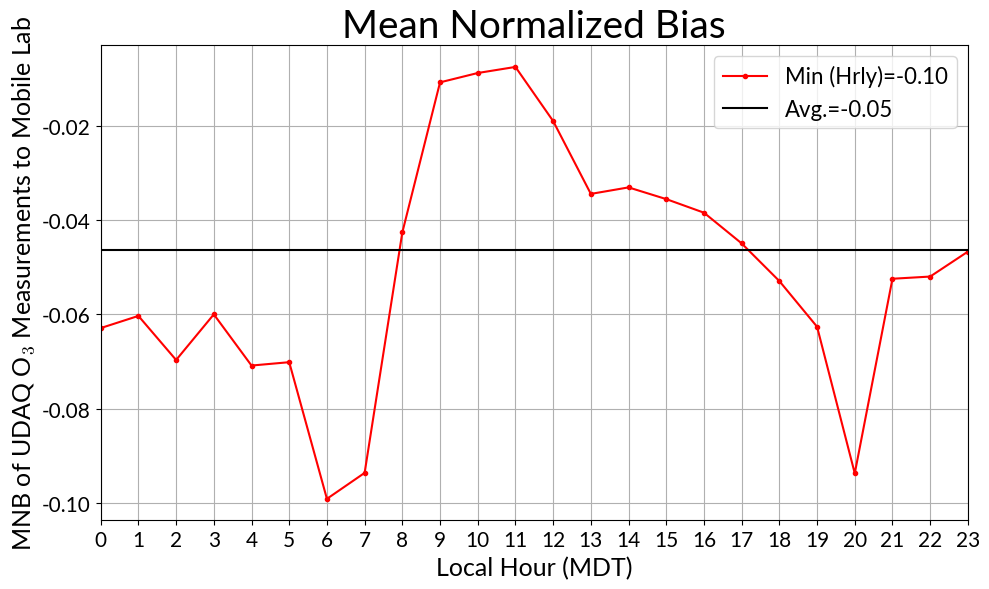

In [235]:
mnb_before_sum = df_o3['O3_diff']/df_o3['obs O3']
df_mnb_before_sum = pd.DataFrame({'mnb_before_sum':mnb_before_sum})
df_mnb_before_sum['hour']=df_mnb_before_sum.index.hour 
mnb_sum_hrly = df_mnb_before_sum.groupby('hour')['mnb_before_sum'].mean()

# Plot the hourly MNB and the average over time: 
plt.figure(figsize=(10,6), tight_layout = True)
plt.plot(mnb_sum_hrly.index, mnb_sum_hrly, color='r', marker='.', label=f"Min (Hrly)={np.min(mnb_sum_hrly):.2f}")
plt.plot(mnb_sum_hrly.index, np.ones(len(mnb_sum_hrly.index))*mnb_total, color='k',label=f"Avg.={mnb_total:.2f}")
#plt.ylim([-0.12, 0])
plt.title('Mean Normalized Bias')
plt.ylabel('MNB of UDAQ O$_3$ Measurements to Mobile Lab')
plt.xlabel('Local Hour (MDT)')
plt.xlim([0, 23])
plt.xticks(hour_range)
plt.grid()
plt.legend()
plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/mean_normalized_bias_o3_hawthorne.png', dpi =150)
plt.show()

# Mean Normalized Bias Error
$\text{MNBE} = \frac{1}{n} \sum_{i=1}^n \left| \frac{M_i - O_i}{O_i} \right|$

In [143]:
df_o3['O3_diff']= df_o3['model O3']-df_o3['obs O3']
mnbe_before_sum = abs(df_o3['O3_diff']/df_o3['obs O3'])
mnbe_sum_term = np.nansum(mnbe_before_sum)
mnbe_total= ((1/(len(df_o3['obs O3']))) * mnbe_sum_term)
print(mnbe_total)

0.05435516637235694


In [144]:
mnbe_before_sum = abs(df_o3['O3_diff']/df_o3['obs O3'])
df_mnbe_before_sum = pd.DataFrame({'mnbe_before_sum':mnbe_before_sum})
df_mnbe_before_sum['hour']=df_mnbe_before_sum.index.hour 
hrly_mnbe = df_mnbe_before_sum.groupby('hour')['mnbe_before_sum'].mean()

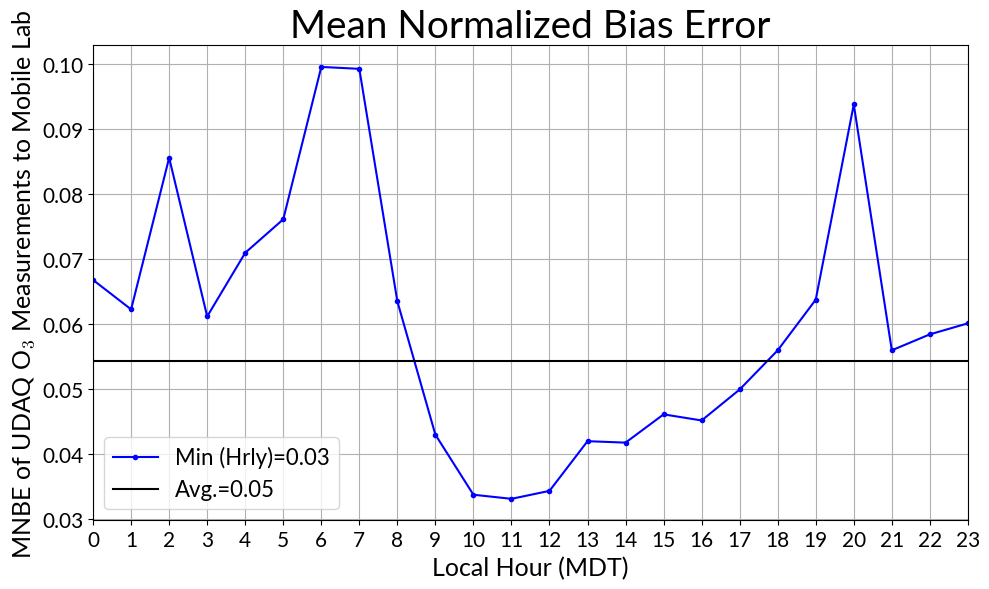

In [220]:
# Plot the hourly MNBE and the average over time: 
plt.figure(figsize=(10,6), tight_layout = True)
plt.plot(hrly_mnbe.index, hrly_mnbe, color='b', marker='.', label=f"Min (Hrly)={np.min(hrly_mnbe):.2f}")
plt.plot(hrly_mnbe.index, np.ones(len(hrly_mnbe.index))*mnbe_total, color='k',label=f"Avg.={mnbe_total:.2f}")
#plt.ylim([-0.14, 0])
plt.title('Mean Normalized Bias Error')
plt.ylabel('MNBE of UDAQ O$_3$ Measurements to Mobile Lab')
plt.xlabel('Local Hour (MDT)')
plt.xlim([0, 23])
plt.xticks(hour_range)
plt.grid()
plt.legend()
plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/mean_normalized_bias_error_o3_hawthorne.png', dpi =150)
plt.show()

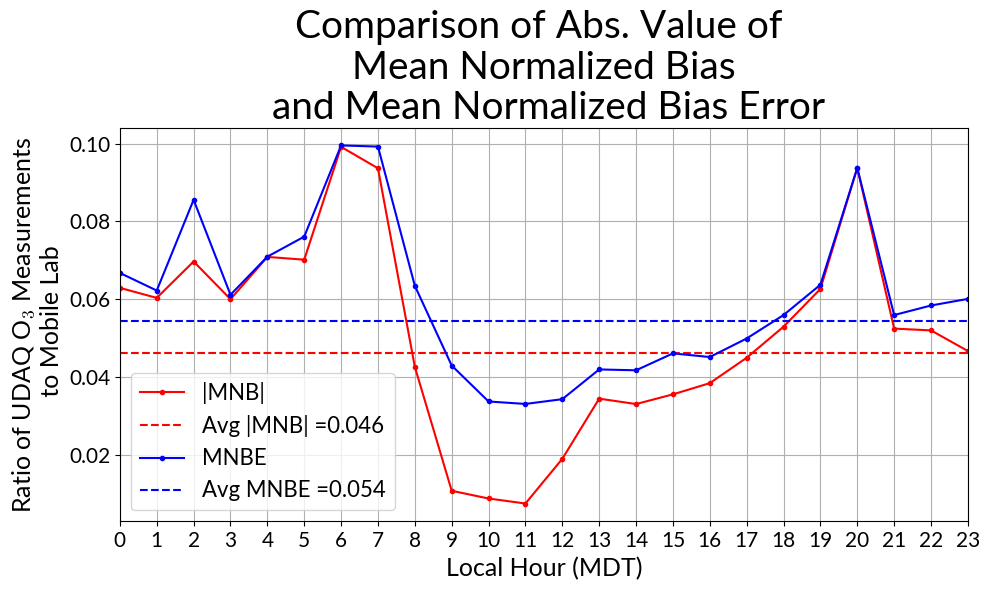

In [224]:
# Plot the hourly MNB and the average over time: 
plt.figure(figsize=(10,6), tight_layout = True)
plt.plot(mnb_sum_hrly.index, mnb_sum_hrly*-1, color='r', marker='.', label=f"|MNB|")
plt.plot(mnb_sum_hrly.index, np.ones(len(mnb_sum_hrly.index))*mnb_total*-1, linestyle='dashed', color='r',label=f"Avg |MNB| ={-1*mnb_total:.3f}")
plt.plot(hrly_mnbe.index, hrly_mnbe, color='b', marker='.', label=f"MNBE")
plt.plot(hrly_mnbe.index, np.ones(len(hrly_mnbe.index))*mnbe_total, linestyle='dashed', color='b',label=f"Avg MNBE ={mnbe_total:.3f}")
#plt.ylim([-0.12, 0])
plt.title('Comparison of Abs. Value of \n Mean Normalized Bias \n and Mean Normalized Bias Error')
plt.ylabel('Ratio of UDAQ O$_3$ Measurements \n to Mobile Lab')
plt.xlabel('Local Hour (MDT)')
plt.xlim([0, 23])
plt.xticks(hour_range)
plt.grid()
plt.legend()
plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/mnbe_and_mnb_hourly_o3_hawthorne.png', dpi =150)
#plt.tight_layout()
plt.show()

---

## Time Series NO2 + O3 (Ox) Comparison

In [236]:
udaq_qc_no2_filepath = dirpath + 'Hawthorne_data/data/hawthorne_udaq_no2_07152024_08012024_timezone_updated.csv'

#Add O3 and NO2 concentrations to get a UDAQ measured Ox Dataframe
df_udaq_no2 = pd.read_csv(udaq_qc_no2_filepath, index_col = 'time_local', parse_dates=True)
udaq_ox_sum= df_udaq_o3_load['UDAQ O3']+df_udaq_no2['UDAQ NO2']
df_ox = pd.DataFrame({'UDAQ O3':df_udaq_o3_load['UDAQ O3'], 'UDAQ NO2':df_udaq_no2['UDAQ NO2'],'UDAQ Ox': udaq_ox_sum})

#Add Mobile Lab measurements of O3 and NO2 to get Ox sum, then put it in the same DataFrame as the UDAQ vals
mobilelab_no2_filepath = dirpath + 'USOS_Campaign_analysis/resaved_data/no2_resampled_hourly.csv'
df_ml_no2 = pd.read_csv(mobilelab_no2_filepath, index_col = 'time_local', parse_dates=True)
ml_ox_sum= mobilelab_o3['Mobile Lab O3']+df_ml_no2['Mobile Lab NO2']
df_ox['ML O3'] = mobilelab_o3['Mobile Lab O3']
df_ox['ML NO2'] = df_ml_no2['Mobile Lab NO2']
df_ox['ML Ox'] = ml_ox_sum



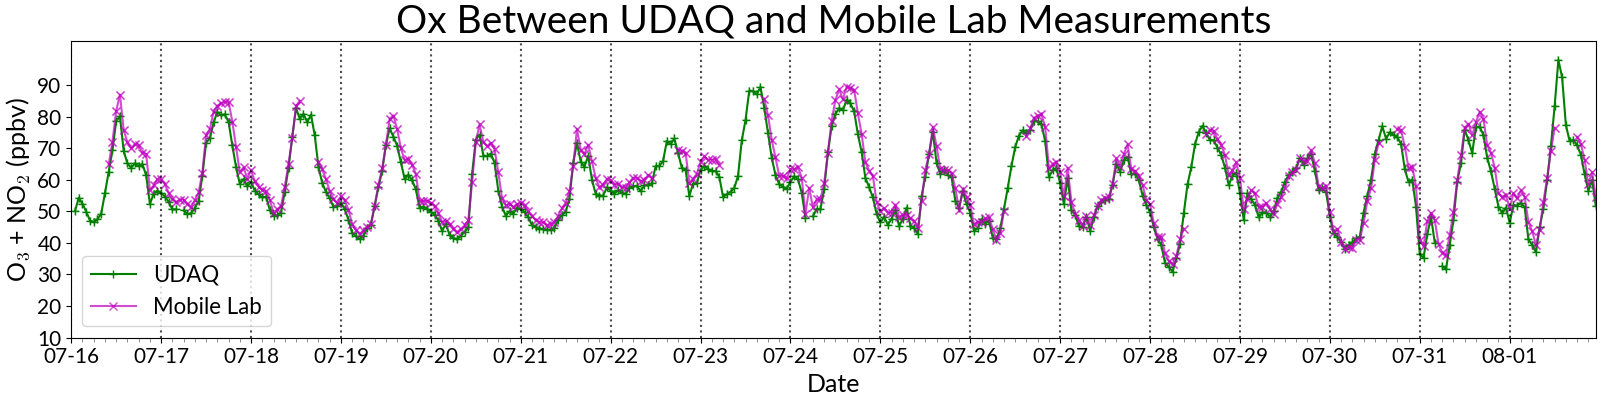

In [237]:
%matplotlib widget
#Full Time Series Plot
fig, ax = plt.subplots(figsize = (16,4), constrained_layout=True)
ax.plot(df_ox.index, df_ox['UDAQ Ox'], linestyle = 'solid', color = 'g', marker = '+', label = 'UDAQ')
ax.plot(df_ox.index, df_ox['ML Ox'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)

pts1 = ax.scatter(df_ox.index, df_ox['UDAQ Ox'], marker = '+', color='g', label = 'UDAQ', alpha = 0.2)
pts2 = ax.scatter(df_ox.index, df_ox['ML Ox'], marker='x', color='m', label = 'Mobile Lab', alpha = 0.2)

#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_ox.index),24):
    midnight_vals.append(df_ox.index[midnight_idx])
for day_pos in midnight_vals:
    ax.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)
#Set x ticks
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax.tick_params(axis='x', which='major')
ax.tick_params(axis='x', which='minor', length=3, color='gray')
#ax.grid(True, which='both')
plt.yticks(np.arange(10,100,10))
plt.ylabel('O$_3$ + NO$_2$ (ppbv)')
plt.xlabel('Date')
plt.margins(x=0)
plt.xlim([pd.to_datetime('2024-07-16 00:00:00'), pd.to_datetime('2024-08-01 23:00:00')])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

plt.title('Ox Between UDAQ and Mobile Lab Measurements')
#plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/hawthorne_udaq_mobilelab_o3_comparison_full_campaign.png', dpi =300)
cursor = mplcursors.cursor([pts1,pts2], multiple=True)
@cursor.connect("add")
def on_add(sel):
    dt_x = mdates.num2date(sel.target[0])
    # y = sel.target[1]
    label = sel.artist.get_label()
    sel.annotation.set_text(f"{label}\n{dt_x:%m-%d %H:%M}, [O3] = {sel.target[1]}")

    # sel.annotation.set_text(f"{label}\nx={dt_x:%m-%d %H:%M}\ny={y}")

plt.show()

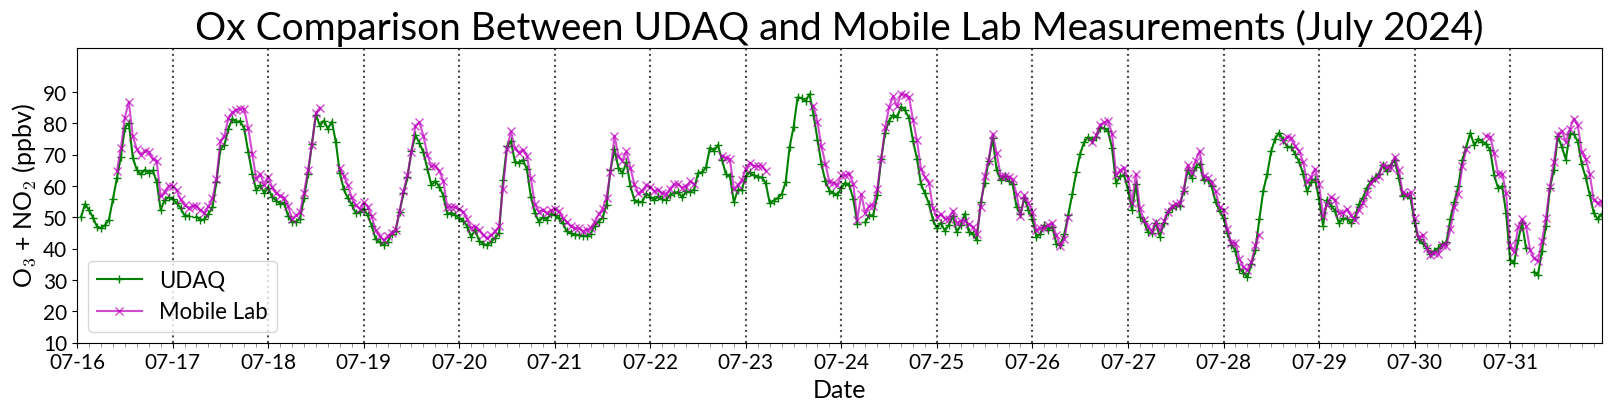

In [239]:
plt.close()
plt.ioff()

%matplotlib inline

#First week time series
fig, ax = plt.subplots(figsize = (16,4), constrained_layout=True)
ax.plot(df_ox.index, df_ox['UDAQ Ox'], linestyle = 'solid', color = 'g', marker = '+', label = 'UDAQ')
ax.plot(df_ox.index, df_ox['ML Ox'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)
#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_ox.index),24):
    midnight_vals.append(df_ox.index[midnight_idx])
for day_pos in midnight_vals:
    ax.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)
#Set x ticks
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax.tick_params(axis='x', which='major')
ax.tick_params(axis='x', which='minor', length=3, color='gray')
#ax.grid(True, which='both')
plt.yticks(np.arange(10,100,10))
plt.ylabel('O$_3$ + NO$_2$ (ppbv)')
plt.xlabel('Date')
plt.margins(x=0)
plt.xlim([pd.to_datetime('2024-07-16 00:00:00'), pd.to_datetime('2024-07-31 23:00:00')])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

plt.title('Ox Comparison Between UDAQ and Mobile Lab Measurements (July 2024)')
plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/hawthorne_udaq_mobilelab_ox_comparison_july.png', dpi =300)
plt.show()


,UDAQ O3,UDAQ NO2,UDAQ Ox,ML O3,ML NO2,ML Ox
2024-07-16 00:00:00,NaN,4.2,NaN,NaN,4.452930,NaN
2024-07-16 01:00:00,46.0,4.1,50.1,NaN,2.797322,NaN
2024-07-16 02:00:00,53.0,1.3,54.3,NaN,1.425817,NaN
2024-07-16 03:00:00,50.0,2.4,52.4,NaN,1.154275,NaN
2024-07-16 04:00:00,46.0,3.9,49.9,NaN,1.936455,NaN
...,...,...,...,...,...,...
2024-07-31 19:00:00,59.0,3.7,62.7,65.723333,2.907799,68.631132
2024-07-31 20:00:00,51.0,6.2,57.2,59.066889,4.807552,63.874441
2024-07-31 21:00:00,46.0,5.5,51.5,51.040667,4.687846,55.728513
2024-07-31 22:00:00,44.0,5.4,49.4,50.057833,4.628535,54.686368


Text(0, 0.5, 'ML O$_x$ (ppb)')

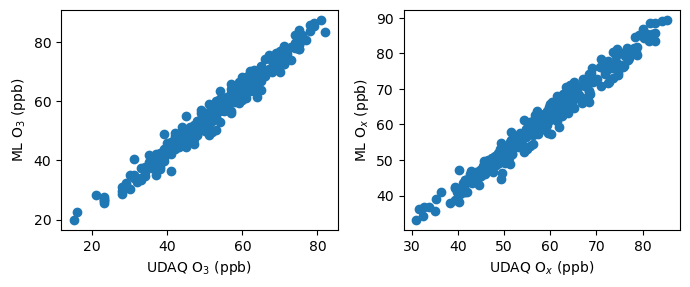

In [67]:
new_start_time = pd.Timestamp('2024-07-16 00:00:00')
new_end_time = pd.Timestamp('2024-07-31 23:00:00')
new_index = pd.date_range(start=new_start_time, end=new_end_time, freq='1h')
df_ox_july = df_ox.copy().reindex(new_index)
display(df_ox_july)

fig, (ax1,ax2) = plt.subplots(nrows = 1, ncols=2, figsize = (7,3), tight_layout=True)

ax1.scatter(df_ox_july['UDAQ O3'], df_ox_july['ML O3'])
ax1.set_xlabel('UDAQ O$_3$ (ppb)')
ax1.set_ylabel('ML O$_3$ (ppb)')

ax2.scatter(df_ox_july['UDAQ Ox'], df_ox_july['ML Ox'])
ax2.set_xlabel('UDAQ O$_x$ (ppb)')
ax2.set_ylabel('ML O$_x$ (ppb)')

